# Task 3: Customer Churn Prediction (Bank Customers)

Dataset(Churn_modelling.csv)
According to given instruction, I have to

1. Clean and prepare the dataset
2. Encode categorical feature such as geography and gender.
3. Train a classification model.
4. Analyze feature importance to understand what influences churn.

# Summary
The objective of this task is to build machine learning classification model that predicts whether a bank customer will leave or stay. This is a real-world business problem used by banks to improve customer retention strategies.

In [3]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [6]:
# load dataset and describing basic structure of it
df = pd.read_csv("bank_churn.csv")
print("Shape of dataset:")
print(df.shape)
print("\n Column Name:")
print(df.columns)
print("\n First 5 rows")
print(df.head())
print("\n Basic Statistics:")
print(df.describe())

Shape of dataset:
(10000, 14)

 Column Name:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

 First 5 rows
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15733321     Brown          727    France    Male   40   
1          2    15712827    Davies          618    France  Female   22   
2          3    15622143  Martinez          726    France  Female   45   
3          4    15642554  Phillips          719    France    Male   32   
4          5    15784357     Clark          697     Spain    Male   47   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0      10  137286.01              2          0               0   
1       9       0.00              2          1               0   
2       9       0.00              1          1               0   
3     

# Cleaning the Dataset

In [8]:
# Removing the unnecessary column
df = df.drop(['RowNumber','CustomerId','Surname'], axis = 1)
#checking missing values
df.isnull().sum().sort_values(ascending = False)

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Exited column is target as a target column to predict whether a bank customer will leave the bank (Exited = 1) or stay (Exited = 0)

In [13]:
# seperating feature and targeted variable
X = df.drop("Exited", axis = 1) # or your target column
y = df["Exited"]

In [14]:
# identifying column types: categorical for text data and numeric for numbers
cat_features = ["Geography", "Gender"]
num_features = [col for col in X.columns if col not in cat_features]

# Preprocessing

In [17]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop = "first"), cat_features)
])

Now numbers will be scaled (0 mean, unit variance) and categorical will be converted into binary columns 

# Pipeline

In [20]:
#Random Forest Pipeline with SMOTE
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state = 42)),
    ("model", RandomForestClassifier(random_state = 42))
])

# Hyperparameter Tuning

In [24]:
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5,10, None],
    "model__min_samples_split": [2,5]
}

# Model Training

In [25]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)
rf_grid = GridSearchCV(rf_pipe, rf_params, cv = 5, scoring = "roc_auc", n_jobs = -1)
rf_grid .fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


# Prediction

In [26]:
y_pred = rf_grid.predict(X_test)
y_prob = rf_grid.predict_proba(X_test)[:,1]

# Evaluation

In [27]:
print("Best parameters:", rf_grid.best_params_)
print("\n Accuracy:", accuracy_score (y_test,y_pred))
print("\n ROC-AUC:", roc_auc_score (y_test,y_pred))
print("\n Confusion Matrix:\n", confusion_matrix (y_test,y_pred))
print("\n Classification Report: \n", classification_report (y_test,y_pred))

Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}

 Accuracy: 0.678

 ROC-AUC: 0.5776974080771549

 Confusion Matrix:
 [[1186  394]
 [ 250  170]]

 Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.75      0.79      1580
           1       0.30      0.40      0.35       420

    accuracy                           0.68      2000
   macro avg       0.56      0.58      0.57      2000
weighted avg       0.72      0.68      0.69      2000



The Random Forest model achieved an accuracy of 67% and ROC-AUC score of 0.58, showing good overall performance in predicting customer exit behavior. The confusion matrix indicates that the most customers were classified correctly, including 1186 non-exited customers and 170 exited customers. The classification report shows strong performance for non-exited customers and moderate performance for exited customers, with the model correctly identifying about 75% of customer who exited the bank.

# Feature Importance

In [36]:
best_rf = rf_grid.best_estimator_
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

#Get importance values from model
importances = best_rf.named_steps["model"].feature_importances_

#Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

#Sort
feature_importances = feature_importance.sort_values(by="Importance", ascending = False)

print(feature_importance.head(10))

                  Feature  Importance
0        num__CreditScore    0.015411
1                num__Age    0.097183
2             num__Tenure    0.067044
3            num__Balance    0.014784
4      num__NumOfProducts    0.017431
5          num__HasCrCard    0.001782
6     num__IsActiveMember    0.017671
7    num__EstimatedSalary    0.022404
8  cat__Geography_Germany    0.310810
9    cat__Geography_Spain    0.177325


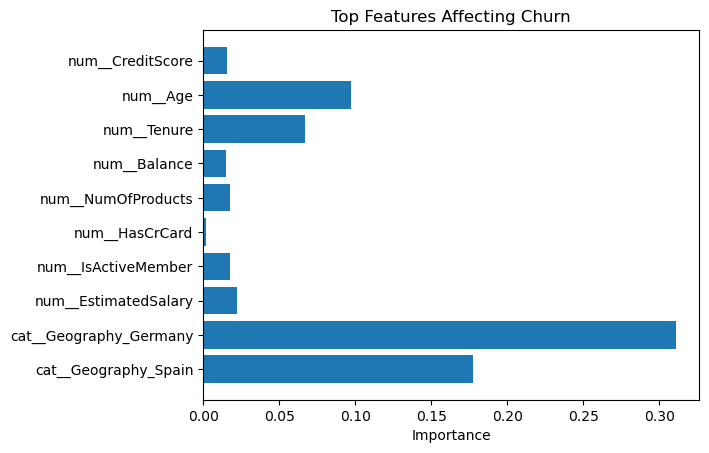

In [37]:
top_features = feature_importance.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Features Affecting Churn")
plt.xlabel("Importance")
plt.show()

Feature importance shows which feature have the greatest influence on predicting whether a customer will exit the bank. In the Random Forest Model, features with higher importance values contribute more to the prediction decision. This helps identify the key factors affecting customer exit behaviour, such as age, balance, or account activity.